# MobileNetV2 Training (Standardized)

Standardized training pipeline matching DenseNet121 reference.

In [1]:
!pip install -q split-folders timm grad-cam

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import timm
import cv2
import numpy as np
import shutil
import glob
import splitfolders
import matplotlib.pyplot as plt
from PIL import Image
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

# Check if running in Colab
if IN_COLAB:
    # Mount the drive if it's not already mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive is already mounted.")
else:
    print("Not running in Colab.")

Not running in Colab.


In [4]:
# Dataset Setup (Local)
import os
import shutil
import splitfolders

# Input dataset path (Local)
input_folder = '../Dataset'
output_folder = 'dataset_split'

if not os.path.exists(input_folder):
    print(f'Error: Dataset not found at {input_folder}')
else:
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder) # Clean previous split
    
    print(f'Splitting dataset from {input_folder} to {output_folder}...')
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .15, .15), group_prefix=None)
    print('Dataset split complete.')


Splitting dataset from ../Dataset to dataset_split...


Copying files: 1030 files [00:00, 4744.11 files/s]

Dataset split complete.


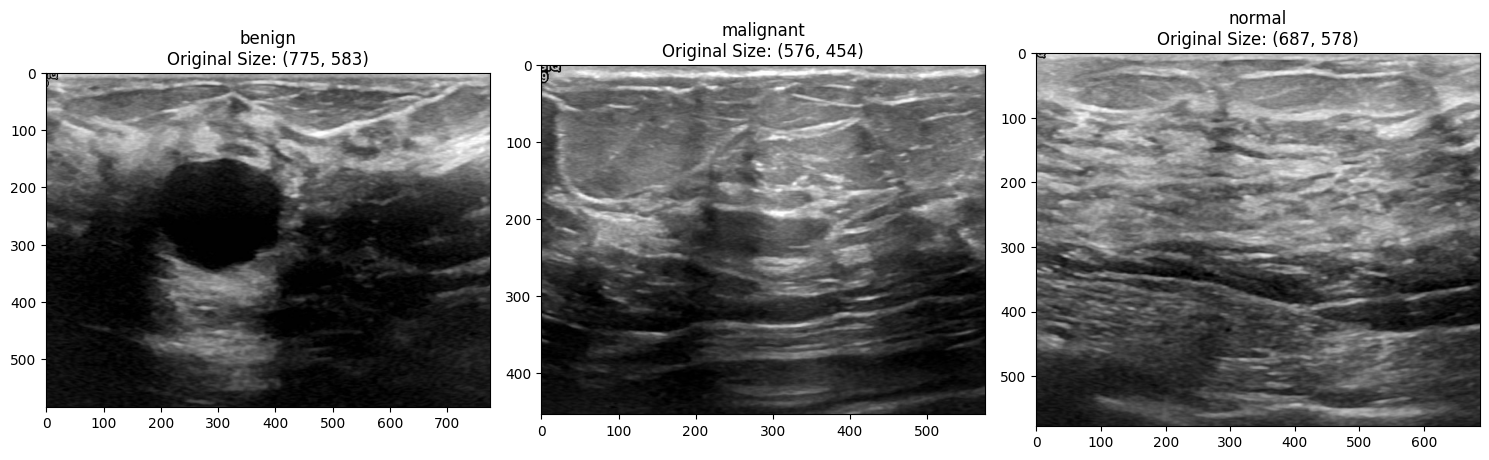

In [5]:
def show_raw_images(dataset_path, num_images=3):
    classes = ['benign', 'malignant', 'normal']
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
            random_img = random.choice(os.listdir(class_folder))
            img_path = os.path.join(class_folder, random_img)
            img = Image.open(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{cls}\nOriginal Size: {img.size}")
            plt.axis('on')
    plt.tight_layout()
    plt.show()

show_raw_images(output_folder)

In [6]:
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

print("UltrasoundEnhancement class created.")

UltrasoundEnhancement class created.


In [7]:
data_transforms = {
    'train': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = output_folder
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset Sizes: {dataset_sizes}")

Classes: ['benign', 'malignant', 'normal']
Dataset Sizes: {'train': 719, 'val': 153, 'test': 158}


In [8]:
def get_model(model_name, num_classes):
    import torch
    import torch.nn as nn
    import timm
    from torchvision import models
    import math
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Creating model: {model_name}...')
    try:
        model = timm.create_model(model_name, pretrained=True)
    except:
        # Fallback
        if 'mobilenet' in model_name:
             model = models.mobilenet_v3_large(pretrained=True)

    # 1. Freeze ALL layers first
    for param in model.parameters():
        param.requires_grad = False

    # 2. Unfreeze last 10% of features
    # MobileNetV3 (timm) usually has 'blocks' or 'features'
    main_block = None
    if hasattr(model, 'blocks'):
        main_block = model.blocks
    elif hasattr(model, 'features'):
        main_block = model.features
    
    if main_block:
        total_layers = len(main_block)
        unfreeze_count = math.ceil(total_layers * 0.3) # 10%
        start_index = total_layers - unfreeze_count
        print(f'Unfreezing last {unfreeze_count} blocks (from index {start_index} to {total_layers-1})...')
        
        for i in range(start_index, total_layers):
            for param in main_block[i].parameters():
                param.requires_grad = True
    else:
        print('Warning: structure not auto-detected for selective unfreeze. Unfreezing last parameter groups instead.')
        params = list(model.parameters())
        cut = int(len(params) * 0.9)
        for p in params[cut:]:
            p.requires_grad = True

    # 3. Replace Head (and ensure it is trainable)
    if hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
             in_features = model.classifier[0].in_features if hasattr(model.classifier[0], 'in_features') else model.classifier[-1].in_features
        else:
             in_features = model.classifier.in_features
        
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 1280),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )
    elif hasattr(model, 'fc'): # Some torchvision models
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Ensure head is trainable (it should be new by default, but just in case)
    if hasattr(model, 'classifier'):
        for param in model.classifier.parameters(): param.requires_grad = True
    elif hasattr(model, 'fc'):
        for param in model.fc.parameters(): param.requires_grad = True

    return model.to(device)


In [9]:
def train_model(model, criterion, optimizer, num_epochs=20):
    import time
    import copy
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [10]:
# Instantiate model
model = get_model(model_name='mobilenetv3_large_100', num_classes=3) # Adjust num_classes if needed
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Creating model: mobilenetv3_large_100...
Unfreezing last 3 blocks (from index 4 to 6)...


In [11]:
# Runtime Setup Fix
num_epochs = 20
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = ['benign', 'malignant', 'normal']
num_classes = len(class_names)
model = get_model('mobilenetv3_large_100', num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, history = train_model(model, criterion, optimizer, num_epochs=num_epochs)

# Save model
torch.save(model.state_dict(), 'mobilenetv3_ultrasound.pth')
print("Model saved as mobilenetv3_ultrasound.pth")

Creating model: mobilenetv3_large_100...
Unfreezing last 3 blocks (from index 4 to 6)...
Epoch 1/20
----------
train Loss: 0.7485 Acc: 0.6384
val Loss: 0.6248 Acc: 0.7582

Epoch 2/20
----------
train Loss: 0.4795 Acc: 0.8067
val Loss: 0.5295 Acc: 0.7974

Epoch 3/20
----------
train Loss: 0.3463 Acc: 0.8581
val Loss: 0.4877 Acc: 0.8301

Epoch 4/20
----------
train Loss: 0.2690 Acc: 0.8901
val Loss: 0.4664 Acc: 0.8039

Epoch 5/20
----------
train Loss: 0.2473 Acc: 0.8985
val Loss: 0.5665 Acc: 0.8170

Epoch 6/20
----------
train Loss: 0.2624 Acc: 0.9040
val Loss: 0.4154 Acc: 0.8497

Epoch 7/20
----------
train Loss: 0.2156 Acc: 0.9138
val Loss: 0.6299 Acc: 0.7778

Epoch 8/20
----------
train Loss: 0.1801 Acc: 0.9374
val Loss: 0.4281 Acc: 0.8366

Epoch 9/20
----------
train Loss: 0.0927 Acc: 0.9736
val Loss: 0.6213 Acc: 0.8627

Epoch 10/20
----------
train Loss: 0.1023 Acc: 0.9638
val Loss: 0.5456 Acc: 0.8497

Epoch 11/20
----------
train Loss: 0.1892 Acc: 0.9318
val Loss: 0.7984 Acc: 0.80

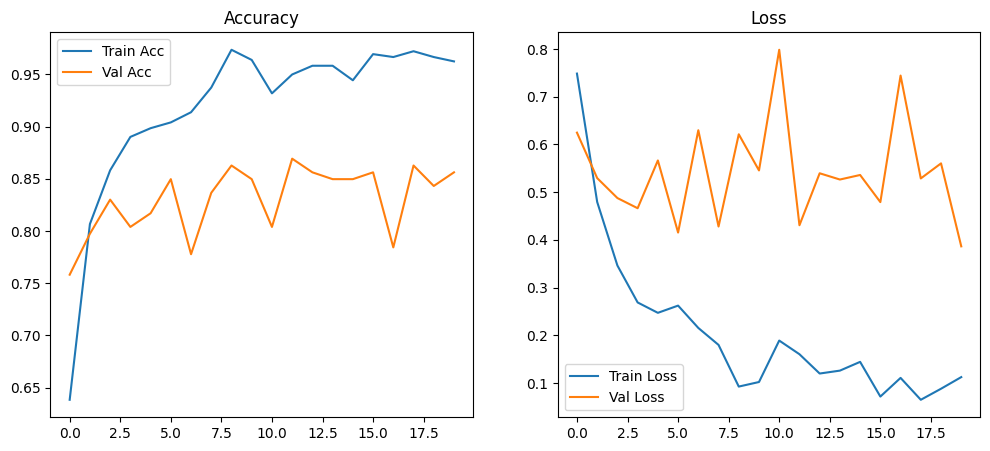

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Evaluating on Test Set...
Classification Report:
              precision    recall  f1-score   support

      benign     0.8750    0.9390    0.9059        82
   malignant     0.9400    0.8545    0.8952        55
      normal     0.9000    0.8571    0.8780        21

    accuracy                         0.8987       158
   macro avg     0.9050    0.8836    0.8931       158
weighted avg     0.9009    0.8987    0.8985       158



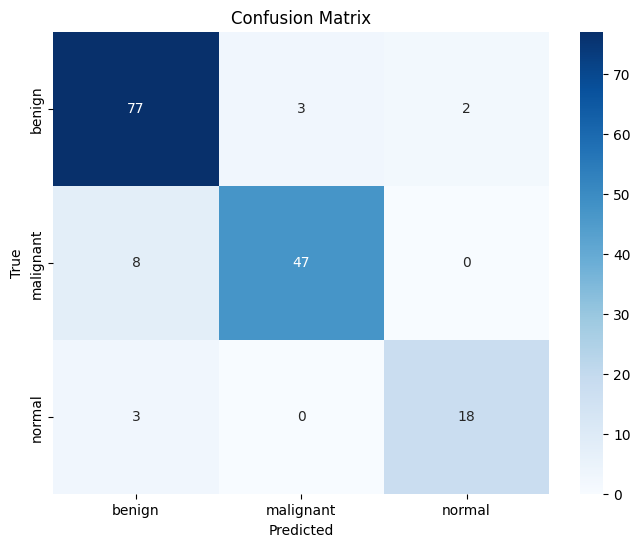

In [13]:
def evaluate_model(model, dataloader):
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import classification_report, confusion_matrix
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

print("Evaluating on Test Set...")
evaluate_model(model, dataloaders['test'])

Showing GradCAM results on Test Set with updated target layer...


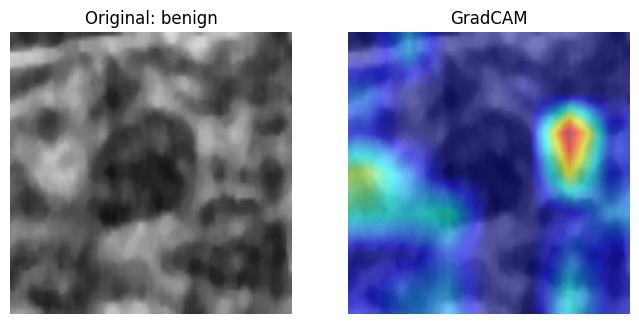

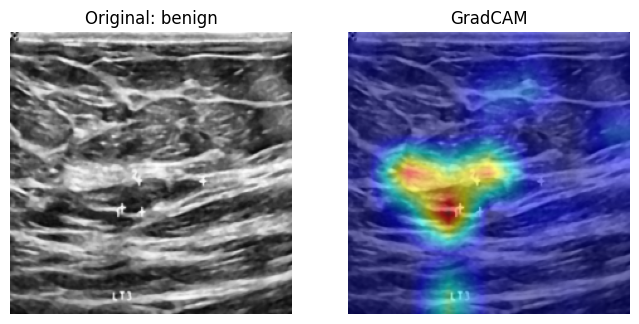

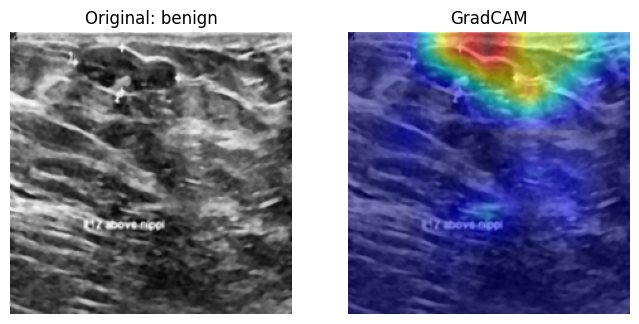

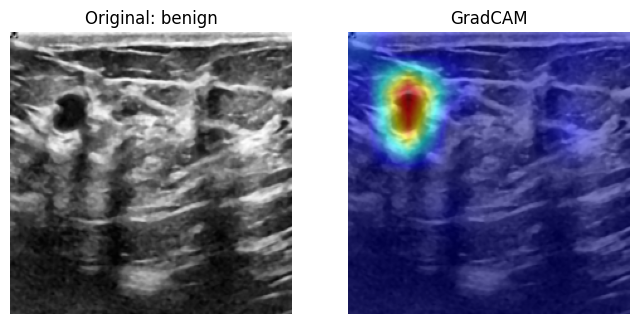

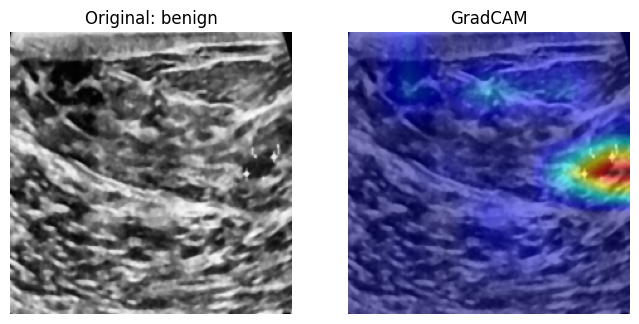

In [14]:
# GradCAM Visualization
model.eval()

# Change target layer to the last block of the feature extractor
# model.blocks[-1] is the last sequence, and [-1] gets the last block within it.
target_layers = [model.blocks[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

def show_gradcam(dataset, num_images=5):
    indices = random.sample(range(len(dataset)), num_images)

    for i in indices:
        img_tensor, label = dataset[i]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        # Generate CAM
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # Prepare original image for visualization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"Original: {class_names[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title("GradCAM")
        plt.axis('off')
        plt.show()

print("Showing GradCAM results on Test Set with updated target layer...")
show_gradcam(image_datasets['test'])

Found 3 manual images to process.
Processing manual image: ../Dataset/malignant/malignant (14).png


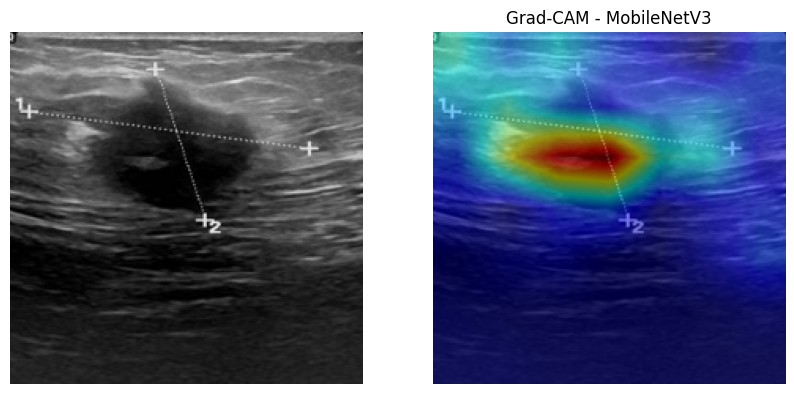

Processing manual image: ../Dataset/benign/benign (2).png


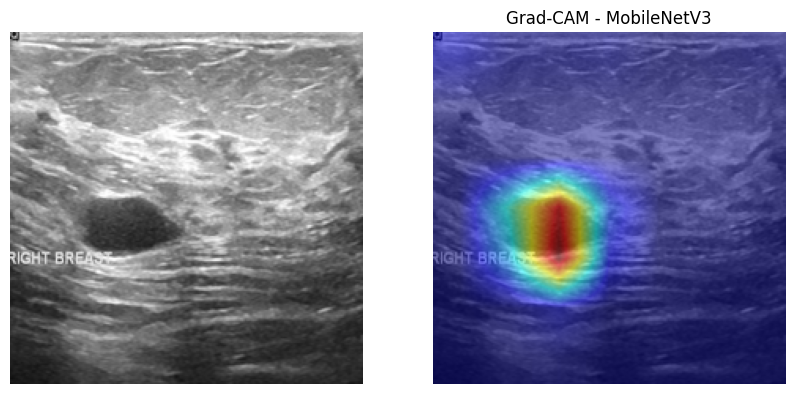

Processing manual image: ../Dataset/normal/normal (4).png


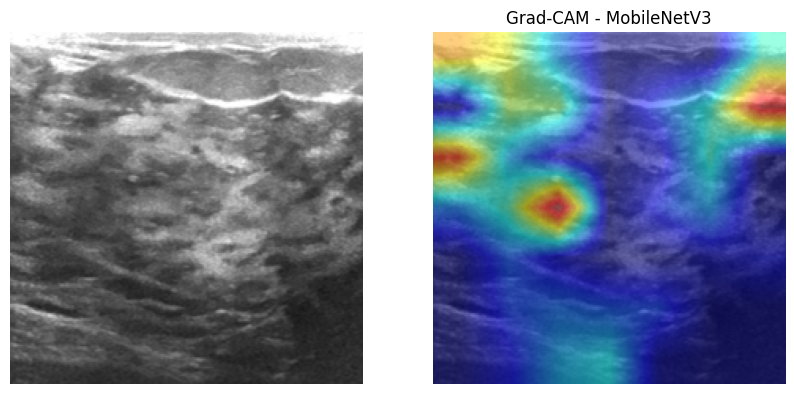

In [20]:
# Grad-CAM Visualization with Manual Path Support
import PIL.Image
import cv2
import numpy as np
import torch
from torchvision import transforms

# --- USER CONFIGURATION ---
# Enter paths to your test images here.
test_image_paths = [
    '../Dataset/malignant/malignant (14).png',
    '../Dataset/benign/benign (2).png',
    '../Dataset/normal/normal (4).png'
]
# --------------------------

def get_target_layers(model):
    if hasattr(model, 'features'): return [model.features[-1]]
    if hasattr(model, 'blocks'): return [model.blocks[-1]]
    if hasattr(model, 'conv_head'): return [model.conv_head]
    # Fallback search
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    if last_conv: return [last_conv]
    raise AttributeError("Could not find a suitable target layer for Grad-CAM")

def predict_single_image_gradcam(model, image_path, class_names):
    print(f"Processing manual image: {image_path}")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        if not os.path.exists(image_path):
            print(f"Error: Image not found at {image_path}")
            return
            
        image = PIL.Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        target_layers = get_target_layers(model)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        
        # Prediction
        with torch.no_grad():
            outputs = model(input_tensor)
            prob = torch.nn.functional.softmax(outputs, dim=1)
            score, preds = torch.max(prob, 1)
            predicted_label = class_names[preds[0]]
            confidence = score.item()
            
        # Visualization
        img_display = np.array(image.resize((224, 224))) / 255.0
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_display)
        ax[0].axis('off')
        
        ax[1].imshow(visualization)
        ax[1].set_title("Grad-CAM - MobileNetV3")
        ax[1].axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing manual image: {e}")
        import traceback
        traceback.print_exc()

def visualize_gradcam_fixed(model, test_dataset, class_names):
    model.eval()
    try:
       target_layers = get_target_layers(model)
    except AttributeError as e:
       print(e); return

    class_indices = {}
    for idx in range(len(test_dataset)):
        _, label = test_dataset[idx]
        class_name = class_names[label]
        if class_name not in class_indices:
            class_indices[class_name] = idx
        if len(class_indices) == len(class_names):
            break
            
    count = len(class_indices)
    fig = plt.figure(figsize=(15, 5 * count))
    
    for i, (class_name, idx) in enumerate(class_indices.items()):
        image, label = test_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        ax = fig.add_subplot(count, 2, 2*i + 1)
        ax.imshow(img_display)
        ax.set_title(f"Original: {class_name}")
        ax.axis('off')
        ax = fig.add_subplot(count, 2, 2*i + 2)
        ax.imshow(visualization)
        ax.set_title(f"Grad-CAM: {class_name}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Execution Logic ---
manual_images_processed = False
if 'test_image_paths' in locals() and test_image_paths:
    print(f"Found {len(test_image_paths)} manual images to process.")
    for img_path in test_image_paths:
        if img_path: # Skip empty strings
            predict_single_image_gradcam(model, img_path, class_names)
            manual_images_processed = True

if not manual_images_processed:
    print("No manual images found/processed. Generating Grad-CAM for fixed examples from dataset...")
    if 'image_datasets' in locals() and 'test' in image_datasets:
        visualize_gradcam_fixed(model, image_datasets['test'], class_names)
    elif 'dataset_test' in locals():
        visualize_gradcam_fixed(model, dataset_test, class_names)
    else:
        print("Error: Test dataset not found.")